# Earthquake Statistics

<a target="_blank" href="https://colab.research.google.com/github/AI4EPS/EPS130_Seismology/blob/main/notebooks/earthquake_statistics_lecture.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

On July 4, 2019, a **M6.4 earthquake** struck near Ridgecrest, California. The next day, an even larger **M7.1 earthquake** hit the same area — the strongest earthquake in California in 20 years.

USGS event page: [ci38457511](https://earthquake.usgs.gov/earthquakes/eventpage/ci38457511/executive)

In this notebook, we'll use the Ridgecrest sequence and global earthquake data to explore the **statistical patterns** that govern earthquake occurrence. These patterns are remarkably simple and universal:

- Small earthquakes are exponentially more frequent than large ones (**Gutenberg-Richter law**)
- Aftershock rates decay as a power law in time (**Omori's law**)
- The largest aftershock is typically ~1.2 magnitude units below the mainshock (**Båth's law**)

In [1]:
!pip install cartopy -q

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import cartopy.crs as ccrs
import cartopy.feature as cfeature

---
## 1. Earthquake Catalogs

An **earthquake catalog** is a database of earthquakes, each with:
- **Origin time** — when the earthquake occurred
- **Location** — latitude, longitude, and depth
- **Magnitude** — size of the earthquake

We use catalogs from the [USGS ComCat](https://earthquake.usgs.gov/earthquakes/search/) database, downloaded via [obspy](https://docs.obspy.org/). Since downloading large catalogs takes a few minutes, we load pre-downloaded CSV files here.

In [2]:
# --- How the catalogs were downloaded using obspy (takes a few minutes) ---
# from obspy.clients.fdsn import Client
# from obspy import UTCDateTime
#
# client = Client("IRIS")
#
# # Global M4+ (2015-2025)
# cat_global = client.get_events(
#     starttime=UTCDateTime("2015-01-01"), endtime=UTCDateTime("2025-01-01"),
#     minmagnitude=4.0,
# )
#
# # Ridgecrest sequence, all magnitudes
# cat_rc = client.get_events(
#     starttime=UTCDateTime("2019-07-01"), endtime=UTCDateTime("2020-01-01"),
#     latitude=35.77, longitude=-117.60, maxradius=0.5,
# )

In [3]:
# Load pre-downloaded catalogs (downloaded from USGS ComCat via obspy)
global_cat = pd.read_csv("https://github.com/AI4EPS/EPS130_Seismology/releases/download/earthquake-statistics-data/global_M4_2015_2025.csv")
global_cat["time"] = pd.to_datetime(global_cat["time"])
print(f"Global catalog: {len(global_cat):,} earthquakes (M4+, 2015-2025)")

ridgecrest = pd.read_csv("https://github.com/AI4EPS/EPS130_Seismology/releases/download/earthquake-statistics-data/ridgecrest_2019.csv")
ridgecrest["time"] = pd.to_datetime(ridgecrest["time"])
ridgecrest = ridgecrest.sort_values("time").reset_index(drop=True)
print(f"Ridgecrest catalog: {len(ridgecrest):,} earthquakes (all magnitudes)")

Global catalog: 149,463 earthquakes (M4+, 2015-2025)


Ridgecrest catalog: 46,046 earthquakes (all magnitudes)


In [4]:
# Identify the mainshock (largest event) and its foreshock
mainshock = ridgecrest.loc[ridgecrest["mag"].idxmax()]  # row with the largest magnitude
mainshock_time = mainshock["time"]

# The M6.4 foreshock: the largest event before the M7.1
foreshock = ridgecrest[(ridgecrest["time"] < mainshock_time) & (ridgecrest["mag"] > 6)].iloc[0]
foreshock_time = foreshock["time"]

print(f"M{foreshock['mag']:.1f} foreshock: {foreshock_time}")
print(f"M{mainshock['mag']:.1f} mainshock: {mainshock_time}")

M6.4 foreshock: 2019-07-04 17:33:49
M7.1 mainshock: 2019-07-06 03:19:53.040000


---
## 2. Global Seismicity Map

Let's plot these earthquakes on a world map. We expect earthquakes to concentrate along **plate boundaries** — the edges of tectonic plates where most of the Earth's seismic energy is released.

/Users/weiqiang/.local/miniconda3/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


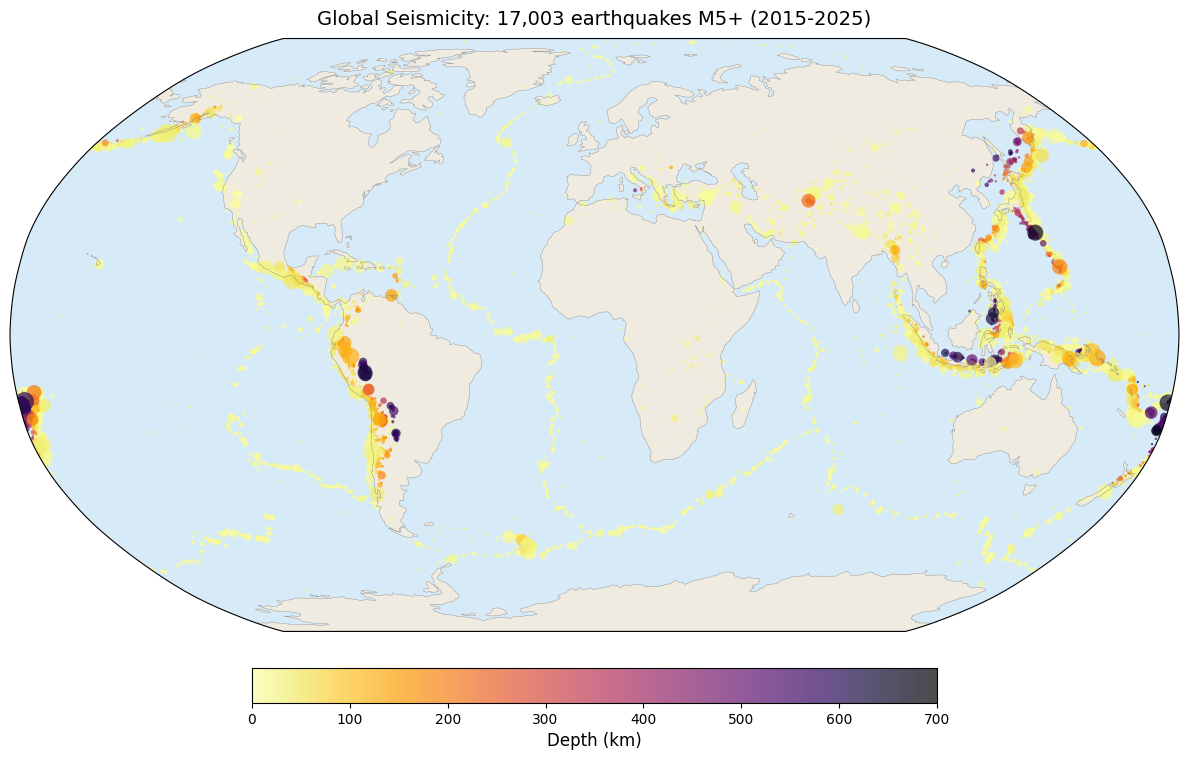

In [5]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()
ax.add_feature(cfeature.OCEAN, facecolor="#d6eaf8")
ax.add_feature(cfeature.LAND, facecolor="#f0ebe0", edgecolor="none")
ax.add_feature(cfeature.COASTLINE, linewidth=0.3, color="#888888")

# Plot M5+ events for a cleaner map (M4 events are too numerous)
m5_plus = global_cat[global_cat["mag"] >= 5.0].sort_values("mag")

# Dot size scales with magnitude
sizes = 3 + (m5_plus["mag"] - 5.0) ** 2.5 * 10

sc = ax.scatter(
    m5_plus["longitude"], m5_plus["latitude"],
    c=m5_plus["depth"], cmap="inferno_r",
    s=sizes, alpha=0.7, vmin=0, vmax=700,
    transform=ccrs.PlateCarree(),
    edgecolors="none",
)

cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.05, shrink=0.5)
cbar.set_label("Depth (km)", fontsize=12)

ax.set_title(f"Global Seismicity: {len(m5_plus):,} earthquakes M5+ (2015-2025)",
             fontsize=14, pad=10)
plt.tight_layout()
plt.show()

The earthquakes trace out the major **tectonic plate boundaries**:

- **Pacific Ring of Fire** — encircles the Pacific Ocean; most seismically active zone on Earth
- **Mid-ocean ridges** — divergent boundaries where new crust forms (all shallow)
- **Alpine-Himalayan belt** — Mediterranean through Iran to the Himalayas

**Deep earthquakes** (dark colors) occur only in **subduction zones**, where one plate dives beneath another.

---
## 3. Earthquake Depth and Rate

Let's look at how earthquakes are distributed with depth, and how the global rate varies over time.

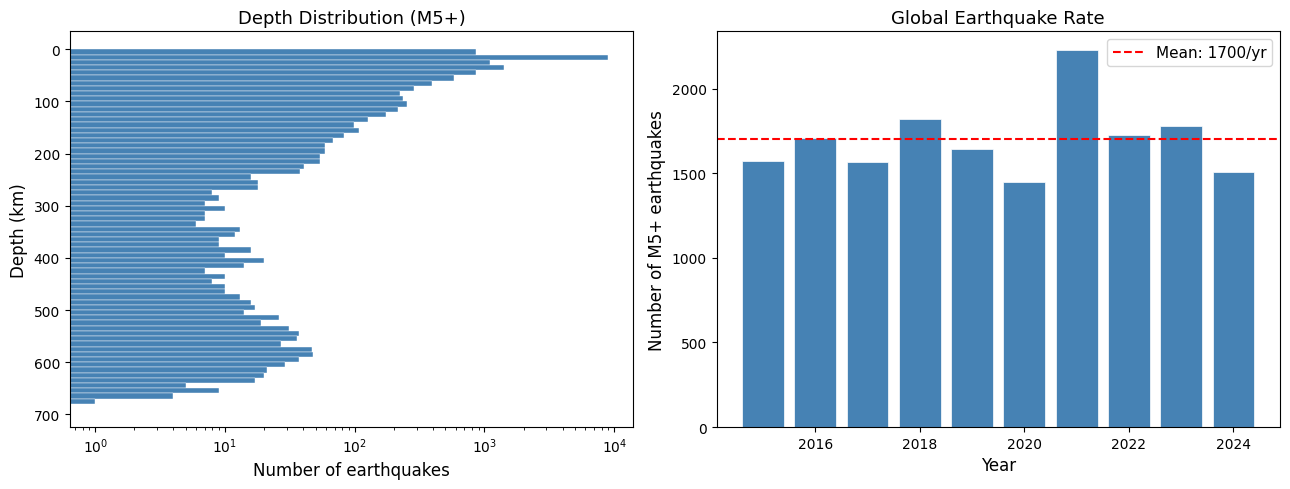

In [6]:
# Use M5+ for depth distribution and rate (cleaner than M4+)
m5_plus = global_cat[global_cat["mag"] >= 5.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Depth distribution (log scale to see the deep-earthquake peak)
axes[0].hist(m5_plus["depth"], bins=np.arange(0, 700, 10), orientation="horizontal",
             color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].set_xscale("log")
axes[0].set_ylabel("Depth (km)", fontsize=12)
axes[0].set_xlabel("Number of earthquakes", fontsize=12)
axes[0].invert_yaxis()
axes[0].set_title("Depth Distribution (M5+)", fontsize=13)

# Right: Count earthquakes per year
m5_plus = m5_plus.copy()
m5_plus["year"] = m5_plus["time"].dt.year
yearly_counts = m5_plus.groupby("year").size()
axes[1].bar(yearly_counts.index, yearly_counts.values, color="steelblue", edgecolor="white", linewidth=0.5)
axes[1].axhline(yearly_counts.mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"Mean: {yearly_counts.mean():.0f}/yr")
axes[1].set_xlabel("Year", fontsize=12)
axes[1].set_ylabel("Number of M5+ earthquakes", fontsize=12)
axes[1].set_title("Global Earthquake Rate", fontsize=13)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

**Depth distribution** (left):
- Most earthquakes are **shallow** (< 70 km) — brittle crust and lithosphere
- Gap at 300–400 km, then a second peak at 500–600 km — **deep-focus earthquakes** in subducting slabs
- Nothing below ~700 km — too hot for brittle fracture

**Global rate** (right):
- About **1,700 M5+ earthquakes per year**, remarkably constant
- This suggests earthquakes can be modeled as a random (**Poisson**) process over long time scales

---
## 4. The 2019 Ridgecrest Sequence

On **July 4, 2019**, a M6.4 earthquake struck near Ridgecrest, California — a small city in the Mojave Desert about 200 km northeast of Los Angeles. Just 34 hours later, on **July 5**, a M7.1 earthquake hit the same area. This was the largest earthquake in California since the 1999 M7.1 Hector Mine earthquake.

The M6.4 event was initially considered the "mainshock" — but after the M7.1 struck, it was reclassified as a "foreshock." This illustrates a fundamental challenge: **we cannot identify a foreshock until after the larger event happens.**

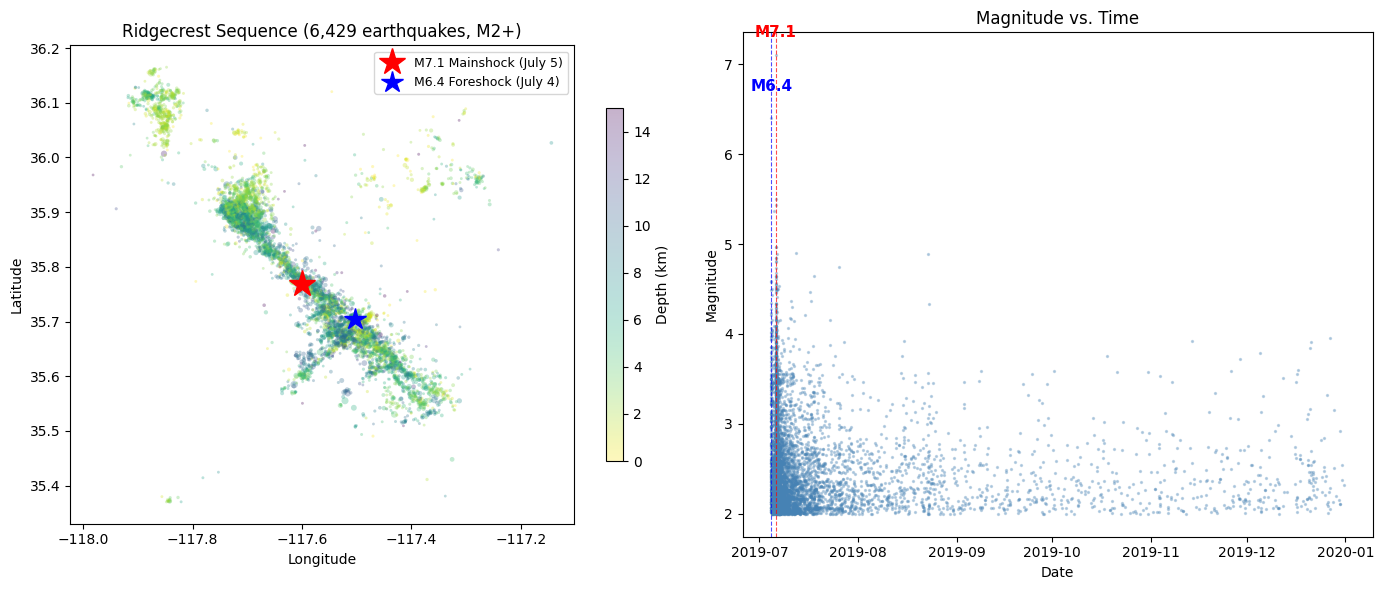

In [7]:
# Use M2+ subset for cleaner visualization
rc_m2 = ridgecrest[ridgecrest["mag"] >= 2.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Map of earthquake locations ---
sizes = 2 ** rc_m2["mag"]  # exponential scaling so large events stand out
sc = axes[0].scatter(
    rc_m2["longitude"], rc_m2["latitude"],
    c=rc_m2["depth"], cmap="viridis_r",
    s=sizes, alpha=0.3, vmin=0, vmax=15,
    edgecolors="none",
)
axes[0].plot(mainshock["longitude"], mainshock["latitude"], "r*", markersize=20,
             label=f"M{mainshock['mag']:.1f} Mainshock (July 5)", zorder=5)
axes[0].plot(foreshock["longitude"], foreshock["latitude"], "b*", markersize=16,
             label=f"M{foreshock['mag']:.1f} Foreshock (July 4)", zorder=5)
cbar = plt.colorbar(sc, ax=axes[0], shrink=0.7)
cbar.set_label("Depth (km)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title(f"Ridgecrest Sequence ({len(rc_m2):,} earthquakes, M2+)", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_aspect("equal")

# --- Right: Magnitude vs. time ---
axes[1].scatter(rc_m2["time"], rc_m2["mag"], s=2, alpha=0.3, color="steelblue")
axes[1].axvline(mainshock_time, color="red", linewidth=0.8, linestyle="--", alpha=0.7)
axes[1].axvline(foreshock_time, color="blue", linewidth=0.8, linestyle="--", alpha=0.7)
axes[1].text(mainshock_time, 7.3, "M7.1", color="red", fontsize=11, ha="center", fontweight="bold")
axes[1].text(foreshock_time, 6.7, "M6.4", color="blue", fontsize=11, ha="center", fontweight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Magnitude")
axes[1].set_title("Magnitude vs. Time", fontsize=12)

plt.tight_layout()
plt.show()

The aftershocks trace out two **conjugate faults** — roughly perpendicular, forming a cross. The M6.4 ruptured a NE-striking fault; the M7.1 ruptured a NW-striking fault.

Notice:
- The burst of activity after each large event — thousands of **aftershocks**
- The gap in small magnitudes right after the mainshock — the network is overwhelmed and **misses small events**

---
## 5. The Gutenberg-Richter Relation

In 1944, Beno Gutenberg and Charles Richter discovered that if you count the cumulative number of earthquakes at or above each magnitude level, the relationship is:

$$\log_{10} N(M) = a - bM \quad \Longleftrightarrow \quad N(M) = 10^{\,a - bM}$$

where:
- $N(M)$ = number of earthquakes with magnitude $\geq M$
- $a$ = overall seismicity rate (higher $a$ = more earthquakes)
- $b$ = slope (typically $b \approx 1$)

A $b$-value of 1 means that for every unit increase in magnitude, there are **10 times fewer** earthquakes. Let's check this with our data.

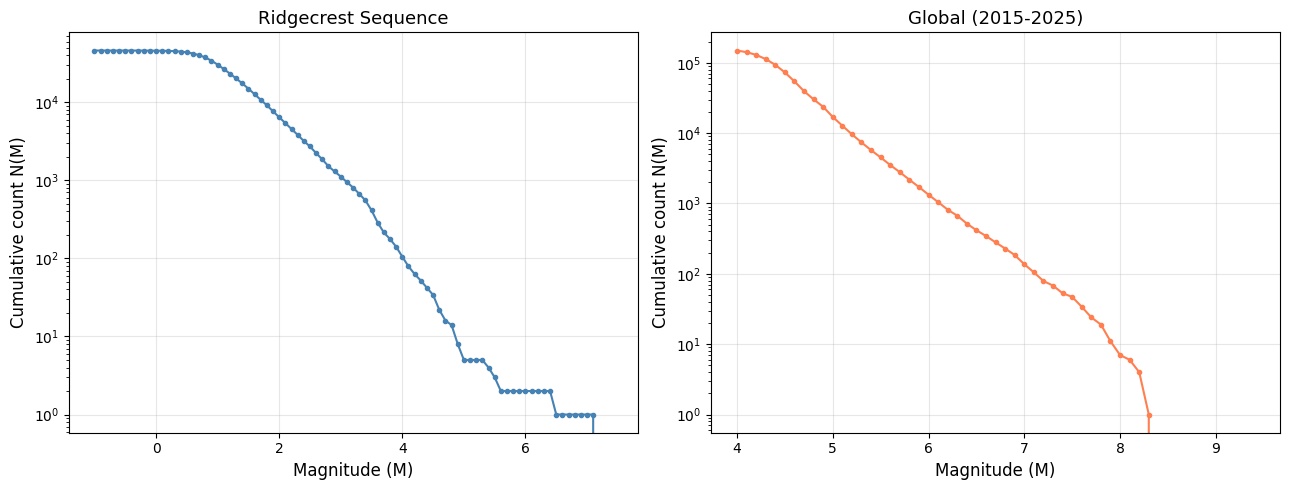

In [8]:
# Cumulative count: N(M) = number of events with magnitude >= M
# This is computed for each magnitude bin
mag_bins_rc = np.arange(-1, 7.5, 0.1)
cum_rc = np.array([np.sum(ridgecrest["mag"] >= m) for m in mag_bins_rc])

mag_bins_gl = np.arange(4.0, 9.5, 0.1)
cum_gl = np.array([np.sum(global_cat["mag"] >= m) for m in mag_bins_gl])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(mag_bins_rc, cum_rc, "o-", color="steelblue", markersize=3)
axes[0].set_xlabel("Magnitude (M)", fontsize=12)
axes[0].set_ylabel("Cumulative count N(M)", fontsize=12)
axes[0].set_title("Ridgecrest Sequence", fontsize=13)
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(mag_bins_gl, cum_gl, "o-", color="coral", markersize=3)
axes[1].set_xlabel("Magnitude (M)", fontsize=12)
axes[1].set_ylabel("Cumulative count N(M)", fontsize=12)
axes[1].set_title("Global (2015-2025)", fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

On a log scale, the data follow a **straight line** at larger magnitudes — this is the Gutenberg-Richter law.

At small magnitudes, the curve **levels off** because the seismic network can't detect all the smallest events. The magnitude where this happens is called the **magnitude of completeness** ($M_c$). We can pinpoint $M_c$ using the magnitude histogram — it peaks at $M_c$ and drops off below it.

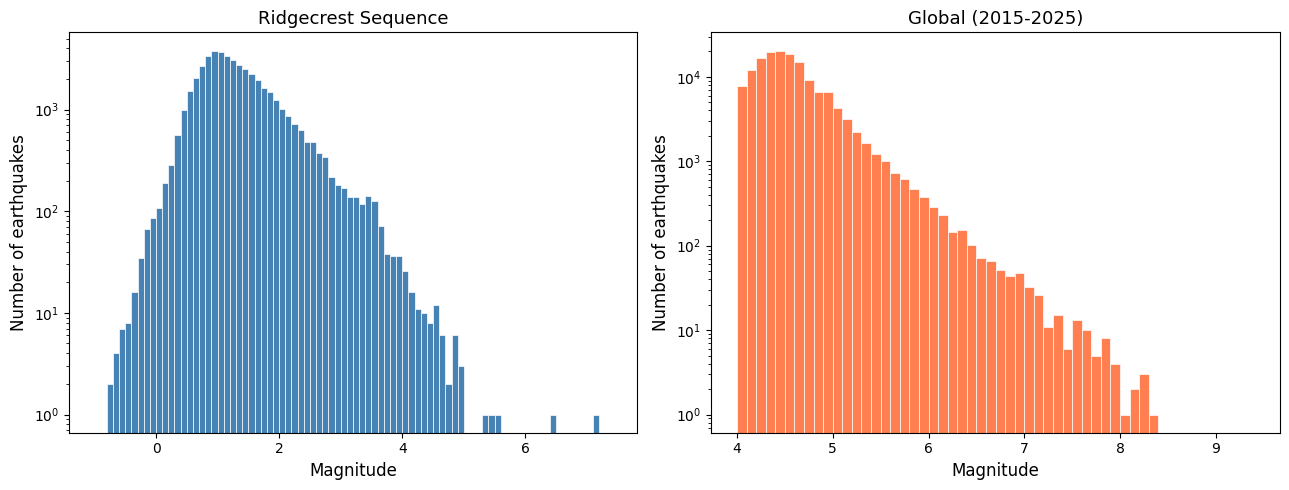

In [9]:
# Magnitude histograms: how many earthquakes at each magnitude?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bins_rc = np.arange(-1.0, 7.5, 0.1)
axes[0].hist(ridgecrest["mag"], bins=bins_rc, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Magnitude", fontsize=12)
axes[0].set_yscale("log")
axes[0].set_ylabel("Number of earthquakes", fontsize=12)
axes[0].set_title("Ridgecrest Sequence", fontsize=13)

bins_gl = np.arange(4.0, 9.5, 0.1)
axes[1].hist(global_cat["mag"], bins=bins_gl, color="coral", edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Magnitude", fontsize=12)
axes[1].set_yscale("log")
axes[1].set_ylabel("Number of earthquakes", fontsize=12)
axes[1].set_title("Global (2015-2025)", fontsize=13)

plt.tight_layout()
plt.show()

A simple rule of thumb: $M_c \approx$ the **peak of the histogram** + 0.2. Below $M_c$, the catalog is incomplete, so we only use data above $M_c$ for fitting the G-R law.

In [10]:
# Estimate Mc from the histogram peak
hist_bins = np.arange(-1.0, 7.5, 0.1)
counts, edges = np.histogram(ridgecrest["mag"], bins=hist_bins)
bin_centers = (edges[:-1] + edges[1:]) / 2
Mc_rc = bin_centers[np.argmax(counts)] + 0.2  # peak + 0.2 correction

# For the global catalog, the network detects M4+ events reliably
Mc_gl = 4.5

print(f"Ridgecrest: Mc = {Mc_rc:.1f}  ({np.sum(ridgecrest['mag'] >= Mc_rc):,} events above Mc)")
print(f"Global:     Mc = {Mc_gl}  ({np.sum(global_cat['mag'] >= Mc_gl):,} events above Mc)")

Ridgecrest: Mc = 1.1  (24,928 events above Mc)
Global:     Mc = 4.5  (73,031 events above Mc)


### Fitting the b-value

Now we fit a line to $\log_{10} N$ vs. $M$ using only data above $M_c$.

In [11]:
# ── Key formula: the Gutenberg-Richter law ──
def gutenberg_richter(M, a, b):
    """Predicted number of earthquakes with magnitude >= M."""
    return 10 ** (a - b * M)

# Fit a line to log10(N) vs M above Mc
mask_rc = (mag_bins_rc >= Mc_rc) & (cum_rc > 0)
slope, intercept = np.polyfit(mag_bins_rc[mask_rc], np.log10(cum_rc[mask_rc]), 1)
b_rc = -slope   # slope is negative, b is positive
a_rc = intercept

mask_gl = (mag_bins_gl >= Mc_gl) & (cum_gl > 0)
slope, intercept = np.polyfit(mag_bins_gl[mask_gl], np.log10(cum_gl[mask_gl]), 1)
b_gl = -slope
a_gl = intercept

print(f"Ridgecrest:  b = {b_rc:.2f},  a = {a_rc:.2f}")
print(f"Global:      b = {b_gl:.2f},  a = {a_gl:.2f}")

Ridgecrest:  b = 0.85,  a = 5.44
Global:      b = 1.11,  a = 9.80


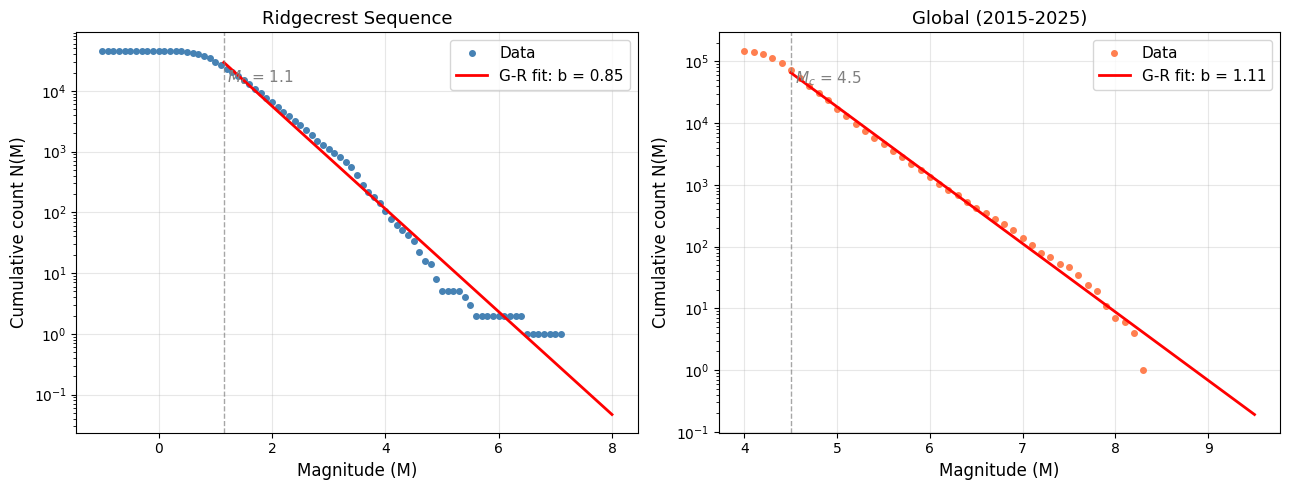

In [12]:
# ── Plotting ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Ridgecrest ----
axes[0].semilogy(mag_bins_rc, cum_rc, "o", color="steelblue", markersize=4, label="Data")
M_plot = np.linspace(Mc_rc, 8, 100)
axes[0].semilogy(M_plot, gutenberg_richter(M_plot, a_rc, b_rc), "r-", linewidth=2,
                 label=f"G-R fit: b = {b_rc:.2f}")
axes[0].axvline(Mc_rc, color="gray", linestyle="--", linewidth=1, alpha=0.7)
axes[0].text(Mc_rc + 0.05, cum_rc.max() * 0.3, f"$M_c$ = {Mc_rc:.1f}", fontsize=11, color="gray")
axes[0].set_xlabel("Magnitude (M)", fontsize=12)
axes[0].set_ylabel("Cumulative count N(M)", fontsize=12)
axes[0].set_title("Ridgecrest Sequence", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ---- Global ----
axes[1].semilogy(mag_bins_gl, cum_gl, "o", color="coral", markersize=4, label="Data")
M_plot_gl = np.linspace(Mc_gl, 9.5, 100)
axes[1].semilogy(M_plot_gl, gutenberg_richter(M_plot_gl, a_gl, b_gl), "r-", linewidth=2,
                 label=f"G-R fit: b = {b_gl:.2f}")
axes[1].axvline(Mc_gl, color="gray", linestyle="--", linewidth=1, alpha=0.7)
axes[1].text(Mc_gl + 0.05, cum_gl.max() * 0.3, f"$M_c$ = {Mc_gl}", fontsize=11, color="gray")
axes[1].set_xlabel("Magnitude (M)", fontsize=12)
axes[1].set_ylabel("Cumulative count N(M)", fontsize=12)
axes[1].set_title("Global (2015-2025)", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Both datasets give $b \approx 1$, confirming the Gutenberg-Richter law is **universal**:

| $b = 1$ means... | |
|:--|:--|
| 10× fewer M5 than M4 | |
| 10× fewer M6 than M5 | |
| 10× fewer M7 than M6 | |

**Why this matters for energy:** Earthquake energy scales as $E \propto 10^{1.5M}$, so a single M7 releases about as much energy as **all smaller earthquakes combined**. The energy budget is dominated by the largest events.

The $b$-value is stable worldwide ($b \approx 1$), but varies locally:
- **Volcanic areas**: $b > 1$ (many small events)
- **Locked faults**: $b < 1$ (relatively more large events)

### How Many M8+ Earthquakes Per Year?

The Gutenberg-Richter law lets us extrapolate from observed rates to estimate how often the largest earthquakes occur.

In [13]:
# Apply the G-R law to predict earthquake rates
years = 10  # the global catalog covers 10 years

print("Expected number of earthquakes per year (from G-R law):")
print("=" * 50)
for M in [5, 6, 7, 8, 9]:
    N_per_year = gutenberg_richter(M, a_gl, b_gl) / years
    if N_per_year >= 1:
        print(f"  M >= {M}:  {N_per_year:.0f} per year")
    else:
        recurrence = 1 / N_per_year
        print(f"  M >= {M}:  1 every {recurrence:.0f} years")

Expected number of earthquakes per year (from G-R law):
  M >= 5:  1826 per year
  M >= 6:  143 per year
  M >= 7:  11 per year
  M >= 8:  1 every 1 years
  M >= 9:  1 every 15 years


---
## 6. Omori's Law

After a large earthquake, hundreds to thousands of **aftershocks** follow. Their rate decays predictably — described by **Omori's law** (1894), one of the oldest empirical laws in seismology.

The **modified Omori law** (Utsu, 1961):

$$\boxed{n(t) = \frac{K}{(t + c)^p}}$$

| Parameter | Meaning | Typical value |
|:----------|:--------|:--------------|
| $n(t)$ | aftershock rate at time $t$ | |
| $K$ | productivity (more aftershocks = larger $K$) | |
| $c$ | small time offset (avoids $1/0$ at $t=0$) | ~0.01–1 day |
| $p$ | decay exponent | $\approx 1$ |

In [14]:
# Select aftershocks: M2+ events after the mainshock
aftershocks = ridgecrest[(ridgecrest["time"] > mainshock_time) & (ridgecrest["mag"] >= 2.0)].copy()

# Time since mainshock in days
aftershocks["dt_days"] = (aftershocks["time"] - mainshock_time).dt.total_seconds() / 86400

print(f"Number of aftershocks (M2+): {len(aftershocks):,}")
print(f"Time span: {aftershocks['dt_days'].min():.4f} to {aftershocks['dt_days'].max():.1f} days")

Number of aftershocks (M2+): 5,718
Time span: 0.0005 to 178.5 days


In [15]:
# To measure the aftershock RATE (events per day), we count events in time bins.
# Log-spaced bins give equal spacing on a log-log plot: fine resolution at
# short times (minutes-hours) and coarser resolution at long times (weeks-months).
bin_edges = np.logspace(np.log10(0.01), np.log10(180), 40)
counts_omori, _ = np.histogram(aftershocks["dt_days"], bins=bin_edges)

# Rate = count / bin width (events per day)
bin_widths = np.diff(bin_edges)
bin_centers_omori = np.sqrt(bin_edges[:-1] * bin_edges[1:])
rates = counts_omori / bin_widths

# Drop empty bins
mask = counts_omori > 0
bin_centers_omori = bin_centers_omori[mask]
rates = rates[mask]

In [16]:
# ── Key formula: the modified Omori law ──
def omori_law(t, K, c, p):
    """Aftershock rate at time t days after the mainshock."""
    return K / (t + c) ** p

# Fit K, c, p to the observed rate data
popt, pcov = curve_fit(omori_law, bin_centers_omori, rates, p0=[100, 0.1, 1.0], maxfev=10000)
K_fit, c_fit, p_fit = popt

print(f"Omori law fit: K = {K_fit:.0f}, c = {c_fit:.3f} days, p = {p_fit:.2f}")

Omori law fit: K = 1285, c = 0.311 days, p = 1.34


/var/folders/gc/lpnp82h92tv35c_7v97w97cm0000gn/T/ipykernel_97461/1817358789.py:4: RuntimeWarning: invalid value encountered in power
  return K / (t + c) ** p


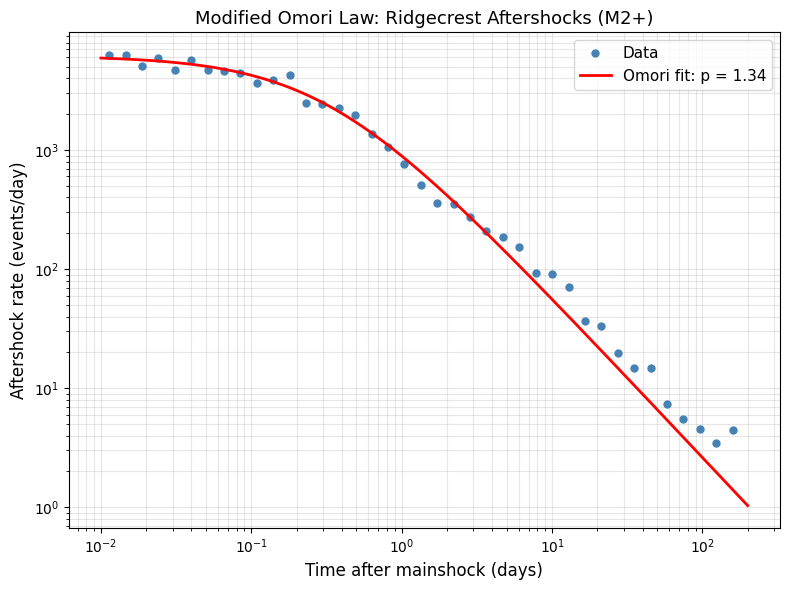

In [17]:
# ── Plotting ──
fig, ax = plt.subplots(figsize=(8, 6))

ax.loglog(bin_centers_omori, rates, "o", color="steelblue", markersize=5, label="Data")
t_plot = np.logspace(-2, np.log10(200), 200)
ax.loglog(t_plot, omori_law(t_plot, *popt), "r-", linewidth=2,
          label=f"Omori fit: p = {p_fit:.2f}")

ax.set_xlabel("Time after mainshock (days)", fontsize=12)
ax.set_ylabel("Aftershock rate (events/day)", fontsize=12)
ax.set_title("Modified Omori Law: Ridgecrest Aftershocks (M2+)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

The fit works well. With $p \approx 1$, the rate decays roughly as $1/t$:

| Time after mainshock | Aftershock rate |
|:-----|:-----|
| 1 day | ~900 events/day |
| 10 days | ~90 events/day |
| 100 days | ~9 events/day |

This is a **power-law decay** — much slower than exponential. The rate never truly reaches zero, which is why aftershock sequences can continue for months or even years.

### Cumulative Aftershock Count

Another way to see the decay: plot the running total of aftershocks over time. The curve rises steeply at first, then flattens.

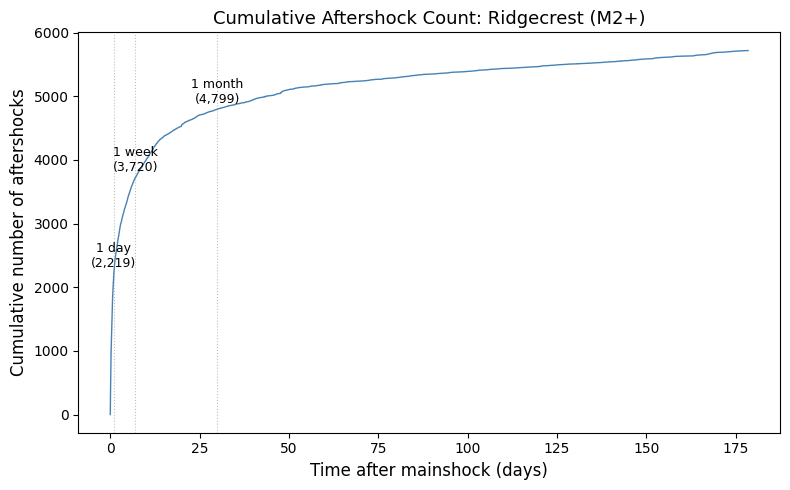

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

# Running total: aftershock #1, #2, #3, ...
cumulative = np.arange(1, len(aftershocks) + 1)
ax.plot(aftershocks["dt_days"], cumulative, color="steelblue", linewidth=1)

# Annotate milestones
for t_mark, label in [(1, "1 day"), (7, "1 week"), (30, "1 month")]:
    n_by_t = np.sum(aftershocks["dt_days"] <= t_mark)
    ax.axvline(t_mark, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
    ax.text(t_mark, n_by_t + 100, f"{label}\n({n_by_t:,})", fontsize=9, ha="center")

ax.set_xlabel("Time after mainshock (days)", fontsize=12)
ax.set_ylabel("Cumulative number of aftershocks", fontsize=12)
ax.set_title("Cumulative Aftershock Count: Ridgecrest (M2+)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Båth's Law and the Foreshock Problem

**Båth's law** (1965) states that the largest aftershock is typically about **1.2 magnitude units** smaller than the mainshock:

$$M_{\text{mainshock}} - M_{\text{largest aftershock}} \approx 1.2$$

In [19]:
# Find the largest aftershock and compare to the mainshock
largest_aftershock = aftershocks.loc[aftershocks["mag"].idxmax()]
mag_diff = mainshock["mag"] - largest_aftershock["mag"]

print(f"Mainshock magnitude:          M{mainshock['mag']:.1f}")
print(f"Largest aftershock magnitude:  M{largest_aftershock['mag']:.1f}")
print(f"Difference:                    {mag_diff:.1f}")
print(f"B\u00e5th's law prediction:         ~1.2")
print(f"\nLargest aftershock occurred {largest_aftershock['dt_days']:.2f} days after the mainshock")

Mainshock magnitude:          M7.1
Largest aftershock magnitude:  M5.5
Difference:                    1.6
Båth's law prediction:         ~1.2

Largest aftershock occurred 0.02 days after the mainshock


The magnitude difference (1.6) is larger than Båth's prediction of 1.2, but there is real variability from sequence to sequence.

The M6.4 occurred **34 hours before** the M7.1. At the time, the M6.4 was the mainshock — it was reclassified as a "foreshock" only after the M7.1 struck. **There is no way to tell whether an earthquake is a foreshock until a larger event occurs.**

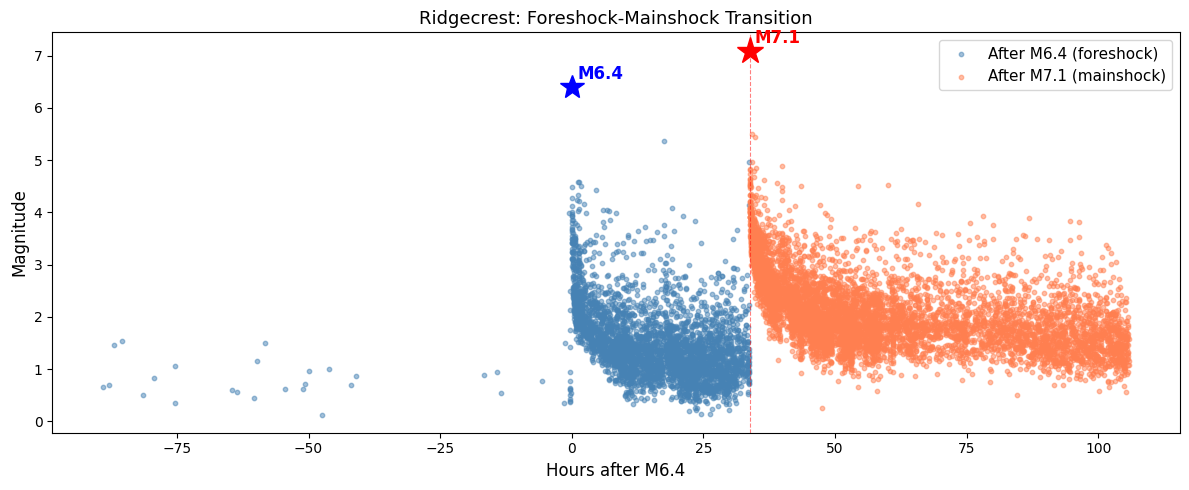

In [20]:
# Zoom in on the first 3 days: show the foreshock -> mainshock transition
early = ridgecrest[ridgecrest["time"] < mainshock_time + pd.Timedelta(days=3)].copy()
early["dt_hours"] = (early["time"] - foreshock_time).dt.total_seconds() / 3600  # hours after M6.4

# Split into events before/after the M7.1
before = early[early["time"] < mainshock_time]
after = early[early["time"] >= mainshock_time]

fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(before["dt_hours"], before["mag"], s=10, color="steelblue", alpha=0.5,
           label="After M6.4 (foreshock)")
ax.scatter(after["dt_hours"], after["mag"], s=10, color="coral", alpha=0.5,
           label="After M7.1 (mainshock)")

# Mark the two big events with stars
ax.plot(0, foreshock["mag"], "b*", markersize=18, zorder=5)
ms_hours = (mainshock_time - foreshock_time).total_seconds() / 3600
ax.plot(ms_hours, mainshock["mag"], "r*", markersize=20, zorder=5)

ax.text(1, foreshock["mag"] + 0.15, f"M{foreshock['mag']:.1f}", color="blue",
        fontsize=12, fontweight="bold")
ax.text(ms_hours + 1, mainshock["mag"] + 0.15, f"M{mainshock['mag']:.1f}", color="red",
        fontsize=12, fontweight="bold")

ax.axvline(ms_hours, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Hours after M6.4", fontsize=12)
ax.set_ylabel("Magnitude", fontsize=12)
ax.set_title("Ridgecrest: Foreshock-Mainshock Transition", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Only about **5% of large earthquakes** have identifiable foreshocks. The M6.4 could not have predicted the M7.1.

This is why earthquake **prediction** ("M7 on Tuesday") remains impossible. What we can do is **forecast** — estimate probabilities using the statistical laws we've learned.

---
## 8. Earthquake Recurrence and Hazard

Over long time periods, large earthquakes on a given fault occur at roughly constant average rates. If we model these as **independent** events, earthquake occurrence follows a **Poisson process**:

$$P(\text{at least 1 event in } T \text{ years}) = 1 - e^{-\lambda T}$$

where $\lambda = 1/\tau$ is the average rate and $\tau$ is the mean recurrence interval.

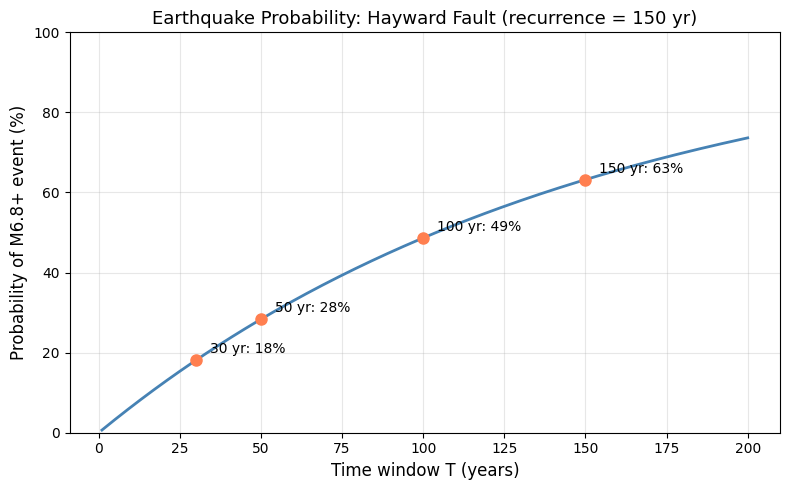

Probability of M6.8+ on Hayward Fault in the next 30 years: 18%

Note: UCERF3 estimates ~33% (higher because the fault is 'overdue' since 1868)


In [21]:
# ── Key formula: Poisson earthquake probability ──
def earthquake_probability(tau, T):
    """Probability of at least one event in T years, given recurrence interval tau."""
    lam = 1 / tau
    return 1 - np.exp(-lam * T)

# Example: Hayward Fault, right next to UC Berkeley
# M6.8+ earthquakes occur roughly every 150 years
# The last major earthquake was in 1868
tau = 150

# ── Plotting ──
T_values = np.arange(1, 201)
prob = earthquake_probability(tau, T_values) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(T_values, prob, color="steelblue", linewidth=2)

for T_mark in [30, 50, 100, 150]:
    p = earthquake_probability(tau, T_mark) * 100
    ax.plot(T_mark, p, "o", color="coral", markersize=8, zorder=5)
    ax.annotate(f"{T_mark} yr: {p:.0f}%", (T_mark, p),
                textcoords="offset points", xytext=(10, 5), fontsize=10)

ax.set_xlabel("Time window T (years)", fontsize=12)
ax.set_ylabel("Probability of M6.8+ event (%)", fontsize=12)
ax.set_title(f"Earthquake Probability: Hayward Fault (recurrence = {tau} yr)", fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

P_30 = earthquake_probability(tau, 30) * 100
print(f"Probability of M6.8+ on Hayward Fault in the next 30 years: {P_30:.0f}%")
print(f"\nNote: UCERF3 estimates ~33% (higher because the fault is 'overdue' since 1868)")

### Aftershock Forecasting

We can combine Gutenberg-Richter and Omori to **forecast aftershocks**. The idea:
1. Use **Omori's law** to predict the rate at a given time
2. Use the **G-R law** to scale to different magnitude thresholds

The USGS issues these forecasts within hours of every significant earthquake.

In [22]:
# Aftershock forecast: combine Omori law (time) with G-R law (magnitude)
def expected_aftershocks(M, t1, t2, M_ref=2.0):
    """Expected number of M+ aftershocks between t1 and t2 days after mainshock."""
    # G-R scaling: ratio of M+ rate to M_ref+ rate
    mag_factor = 10 ** (-b_rc * (M - M_ref))
    # Integrate Omori law from t1 to t2
    time_integral = K_fit / (1 - p_fit) * ((t2 + c_fit)**(1 - p_fit) - (t1 + c_fit)**(1 - p_fit))
    return mag_factor * time_integral

print("Aftershock forecast starting 1 day after M7.1 Ridgecrest mainshock:")
print("=" * 60)

for window_label, t1, t2 in [("Next day (day 1-2)", 1, 2),
                               ("Next week (day 1-8)", 1, 8),
                               ("Next month (day 1-31)", 1, 31)]:
    print(f"\n{window_label}:")
    for M_threshold in [3.0, 4.0, 5.0]:
        N = expected_aftershocks(M_threshold, t1, t2)
        if N >= 1:
            print(f"  M >= {M_threshold}: ~{N:.0f} expected")
        else:
            print(f"  M >= {M_threshold}: ~{N:.1f} expected ({N*100:.0f}% chance of at least one)")

Aftershock forecast starting 1 day after M7.1 Ridgecrest mainshock:

Next day (day 1-2):
  M >= 3.0: ~86 expected
  M >= 4.0: ~12 expected
  M >= 5.0: ~2 expected

Next week (day 1-8):
  M >= 3.0: ~228 expected
  M >= 4.0: ~32 expected
  M >= 5.0: ~5 expected

Next month (day 1-31):
  M >= 3.0: ~322 expected
  M >= 4.0: ~46 expected
  M >= 5.0: ~7 expected


---
## Summary

| Law | Equation | Key result |
|:----|:---------|:-----------|
| **Gutenberg-Richter** | $\log_{10} N = a - bM$ | $b \approx 1$: 10× fewer events per magnitude unit |
| **Omori** | $n(t) = K/(t+c)^p$ | $p \approx 1$: aftershock rate decays as $\sim 1/t$ |
| **Båth** | $\Delta M \approx 1.2$ | Largest aftershock ~1.2 units below mainshock |
| **Poisson** | $P = 1 - e^{-\lambda T}$ | Long-term earthquake probability |

These simple laws are the foundation of **probabilistic seismic hazard analysis** — we cannot predict individual earthquakes, but we can quantify their probabilities.